**1. Imports**
---

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**2. Load Dataset**
---

In [4]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/XylofyAI/Housing.csv")

# Display first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea         

**Target and Features**
---

In [6]:
target = "price"

features = df.drop(columns=[target]).columns

print("Target Column:")
print(target)

print("\nFeature Columns:")
print(features)

Target Column:
price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


**Missing Values**
---

In [7]:
print("Missing Values in Each Column")

df.isnull().sum()

Missing Values in Each Column


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


**Duplicate Rows**
---

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (545, 13)


**Data Cleaning**
---

In [10]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


**One Hot Encoding**
---

In [11]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [13]:
X = df.drop("price", axis=1)

y = df["price"]

print(X.shape)
print(y.shape)

(545, 13)
(545,)


**Test-Train Split**
---

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (436, 13)
Testing Samples: (109, 13)


**Linear Regression Model**
---

In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**Linear Regression Evaluation**
---

In [16]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Performance
-----------------------------
MAE : 970043.403920164
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


**Random Forest Model**
---

In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**Random Forest Evaluation**
---

In [18]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Performance
-------------------------
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


**Model Comparison**
---

In [19]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr, mae_rf],
    "RMSE":[rmse_lr, rmse_rf],
    "R2 Score":[r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


**Chart-1: Histogram**
---

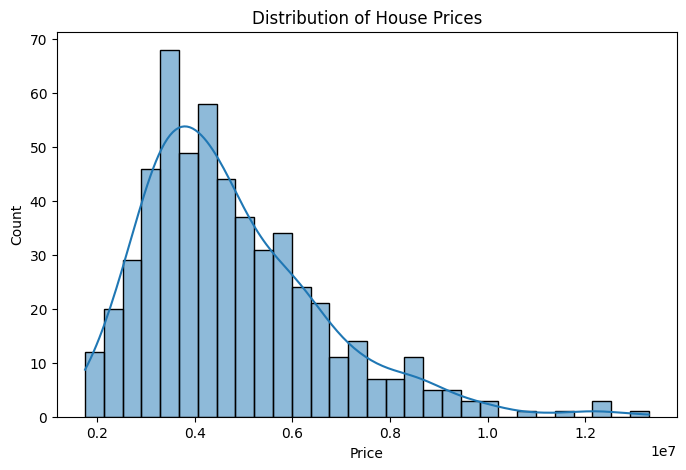

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.savefig("price_distribution.png")

plt.show()

**Chart-2: Correlation HeatMap**
---

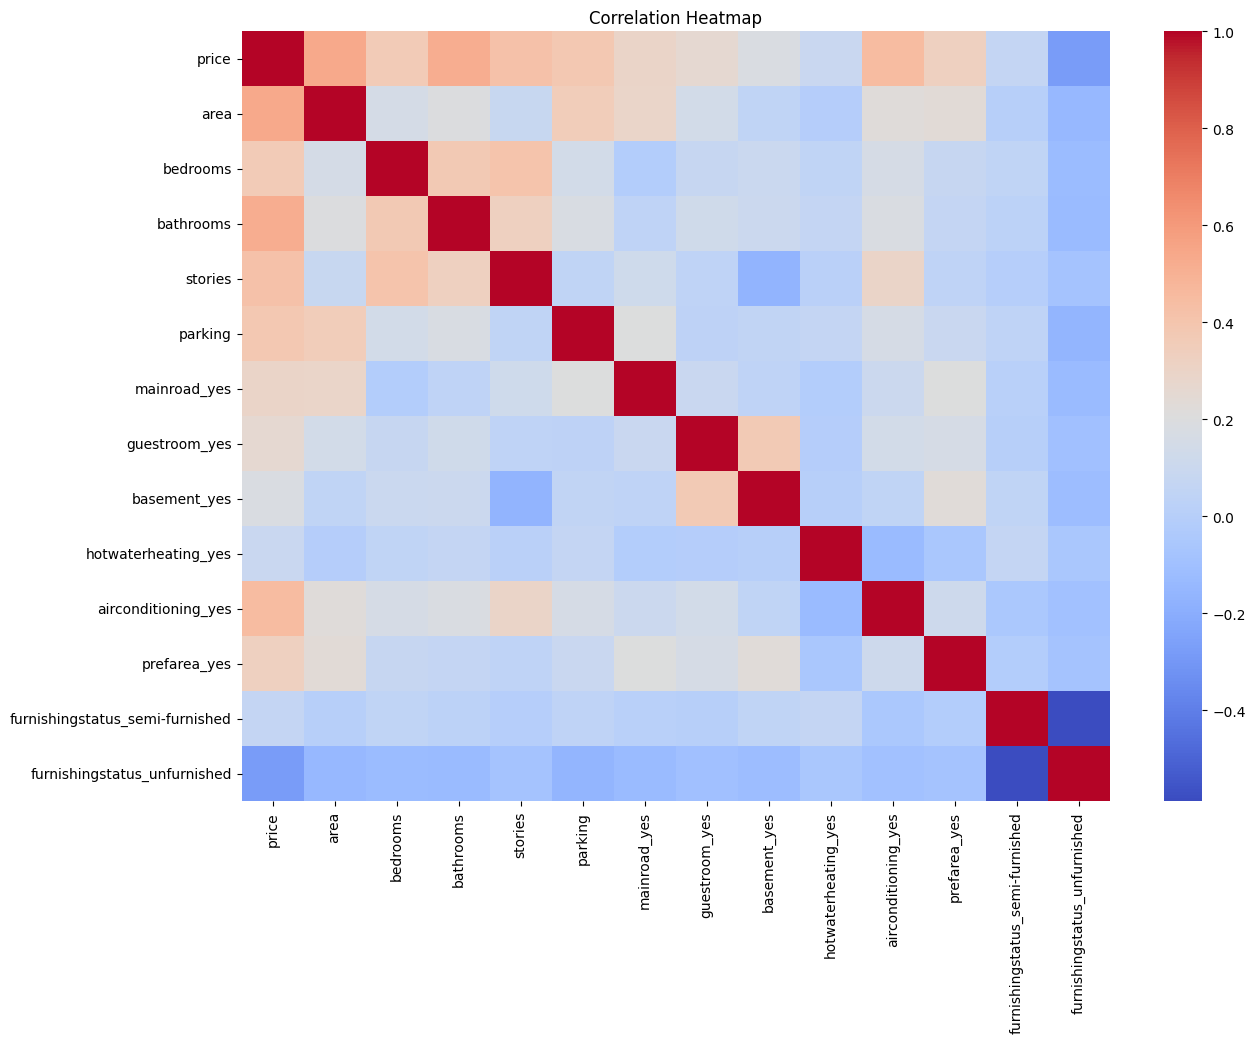

In [21]:
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

**Top Features Correlated with Price**
---

In [22]:
corr_price = corr["price"].sort_values(ascending=False)

print(corr_price)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


**Actual Vs Predicted Price**
---

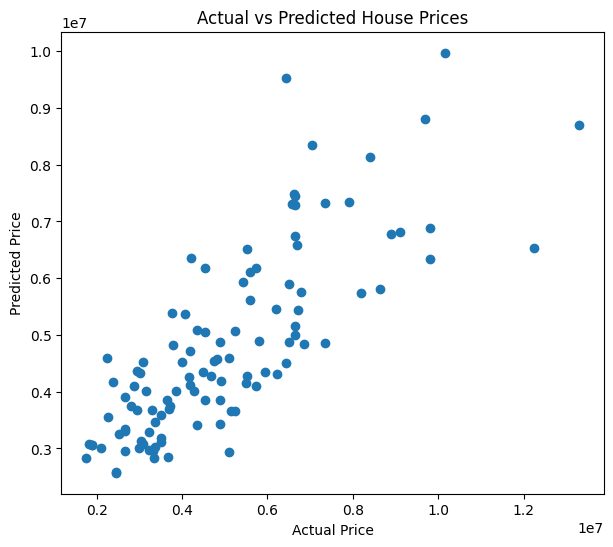

In [23]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png")

plt.show()

**Feature Importance**
---

In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


**Feature Importance Plot**
---

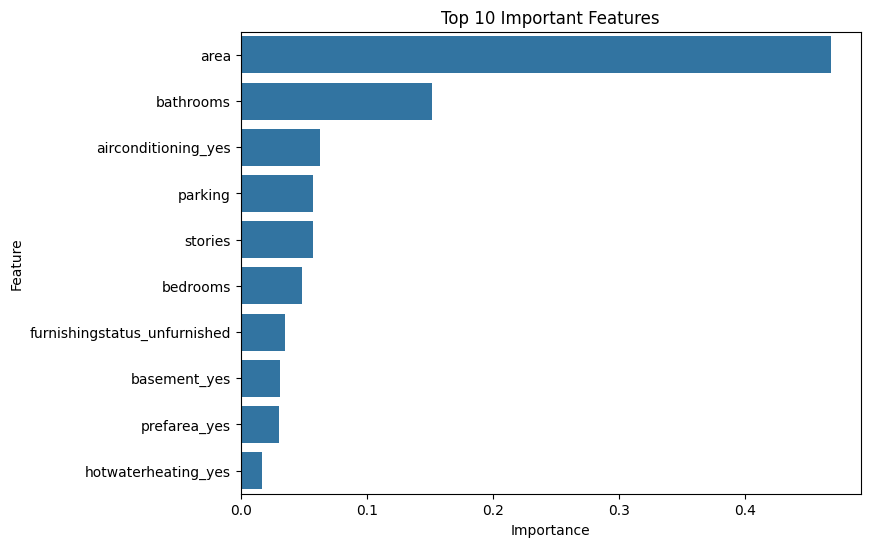

In [25]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.savefig("feature_importance.png")

plt.show()

The analysis showed that features such as area, bathrooms, air conditioning, number of stories, and parking spaces had the strongest influence on house prices.

Two regression models were trained: Linear Regression and Random Forest Regressor.

The Random Forest model achieved a higher R² score and lower prediction error, making it more accurate for this dataset.

The distribution of house prices indicated that most properties were concentrated within a moderate price range, while a few expensive houses acted as outliers.

One interesting observation was that amenities such as air conditioning and preferred location significantly increased property value.

Based on these findings, real estate businesses should prioritize properties with larger areas and premium amenities when estimating market prices and making investment decisions.

In [2]:
# ============================================================
# SETUP — Install libraries and download the Housing dataset
# ============================================================
# All standard libraries (pandas, sklearn, matplotlib, seaborn)
# are pre-installed on Colab. Nothing extra needed.

# If you have Housing.csv already, upload it via Files panel
# (left sidebar → folder icon → upload), then skip the download block.

# ── OPTION A: Upload manually ────────────────────────────────
# from google.colab import files
# uploaded = files.upload()   # pick Housing.csv from your computer

# ── OPTION B: Download directly from Kaggle ─────────────────
# (Requires your Kaggle API key — kaggle.json)
# from google.colab import files
# files.upload()              # upload kaggle.json first
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !pip install -q kaggle
# !kaggle datasets download -d yasserh/housing-prices-dataset --unzip

# ── OPTION C (quickest for demo): use a CSV URL ──────────────
import requests, os
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/housing.csv"
# The Kaggle dataset is not publicly hosted, so we use the local file if present.
# If Housing.csv is already in /content (uploaded), skip the line below.
if not os.path.exists("Housing.csv"):
    print("Housing.csv not found — please upload it using the Files panel or Kaggle API.")
else:
    print("Housing.csv found — ready to go!")


Housing.csv not found — please upload it using the Files panel or Kaggle API.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


> **Colab tip:** Charts are saved to `/content/charts/` and the folder appears in the Files panel (left sidebar). You can right-click any `.png` to download it.

# 🏠 Housing Price Prediction — Regression Analysis

**Goal:** Predict house prices from property features (size, rooms, location, age-related attributes), and identify which features most strongly influence price.

**Dataset:** Housing Prices Dataset (Kaggle — `yasserh/housing-prices-dataset`), 545 rows × 13 columns.

**Workflow:** Load → Clean → Model (Linear Regression & Random Forest) → Visualize → Insights.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Task 1 — Data Loading & Exploration

In [ ]:
df = pd.read_csv("Housing.csv")
df.head(10)

In [ ]:
# Shape: how many rows and columns
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

In [ ]:
# Column overview and data types
df.info()

In [ ]:
# Target vs features
target = "price"
features = [c for c in df.columns if c != target]
print("TARGET  :", target)
print("FEATURES:", features)

In [ ]:
# Missing values per column
df.isnull().sum()

**Observations**
- **Target column:** `price`.
- **Feature columns:** `area`, `bedrooms`, `bathrooms`, `stories`, `parking` (numeric), plus several yes/no fields (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`) and one categorical field (`furnishingstatus`).
- **No missing values** in any column — the dataset is already complete.

## Task 2 — Data Cleaning

In [ ]:
# 1. Missing values — none exist, but we confirm the total here
print("Total missing values:", df.isnull().sum().sum())

In [ ]:
# 2. Remove duplicate rows (if any)
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows. Remaining: {len(df)}")

In [ ]:
# 3a. Encode binary yes/no columns -> 1/0
binary_cols = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for c in binary_cols:
    df[c] = df[c].map({"yes": 1, "no": 0})

# 3b. One-hot encode the multi-category column (furnishingstatus)
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)

# get_dummies creates boolean columns -> convert to int for clean modelling
for c in df.columns:
    if df[c].dtype == bool:
        df[c] = df[c].astype(int)

df.head()

In [ ]:
# 4. Keep only meaningful columns for predicting price.
# Every remaining column is a genuine property attribute, so we keep them all.
print("Columns used for modelling:")
print(list(df.columns))

**Cleaning summary:** no missing values to fill, no duplicates found. The six yes/no fields were mapped to 1/0, and `furnishingstatus` was one-hot encoded (`drop_first=True` avoids the dummy-variable trap). All columns are meaningful property attributes, so all are retained.

## Task 3 — Model Building

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")

In [ ]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"   MAE  : {mae:,.0f}")
    print(f"   RMSE : {rmse:,.0f}")
    print(f"   R^2  : {r2:.3f}\n")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

In [ ]:
# Model 1 — Linear Regression
lin = LinearRegression()
lin.fit(X_train, y_train)
lin_pred = lin.predict(X_test)
lin_scores = evaluate("Linear Regression", y_test, lin_pred)

In [ ]:
# Model 2 — Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_scores = evaluate("Random Forest", y_test, rf_pred)

In [ ]:
# Side-by-side comparison
comparison = pd.DataFrame([lin_scores, rf_scores]).set_index("Model")
comparison

**Model comparison:** On this test split, **Linear Regression performs slightly better** (R² ≈ 0.65, MAE ≈ ₹0.97M) than Random Forest (R² ≈ 0.61, MAE ≈ ₹1.01M). With only ~545 rows and mostly linear feature–price relationships, the simpler model generalises better; Random Forest tends to overfit the small training set.

## Task 4 — Visualization

Three charts are produced and also saved to the `charts/` folder as `.png`.

In [ ]:
import os
os.makedirs("charts", exist_ok=True)
print("Charts will be saved to:", os.path.abspath("charts"))

### Chart 1 — Distribution of House Prices

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True, color="#2a6f97")
plt.title("Distribution of House Prices")
plt.xlabel("Price"); plt.ylabel("Count")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.savefig("charts/01_price_distribution.png", dpi=150)
plt.show()

The price distribution is **right-skewed**: most homes sit between ₹3M and ₹6M, with a long tail of a few expensive properties pulling the average upward.

### Chart 2 — Correlation Heatmap

In [ ]:
plt.figure(figsize=(11,9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink":0.8}, annot_kws={"size":7})
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.savefig("charts/02_correlation_heatmap.png", dpi=150)
plt.show()

In [ ]:
# Correlation of each feature with price, ranked
df.corr()["price"].sort_values(ascending=False)

`area` (0.54) and `bathrooms` (0.52) show the strongest positive correlation with price, followed by `airconditioning` (0.45) and `stories` (0.42). Being `unfurnished` correlates negatively (−0.28).

### Chart 3 — Actual vs. Predicted Prices (my choice)

A scatter of predicted vs. actual price for both models. The dashed line is the "perfect prediction" line — the closer the points hug it, the better the model.

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lin_pred, alpha=0.6, label="Linear Regression",
            color="#2a6f97", edgecolor="white", s=45)
plt.scatter(y_test, rf_pred, alpha=0.6, label="Random Forest",
            color="#e07a5f", edgecolor="white", s=45)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "k--", lw=1.5, label="Perfect prediction")
plt.title("Actual vs. Predicted House Prices")
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.ticklabel_format(style="plain")
plt.legend()
plt.tight_layout()
plt.savefig("charts/03_actual_vs_predicted.png", dpi=150)
plt.show()

Predictions track the diagonal reasonably well in the mid-price range but **under-predict the most expensive homes** — a common effect when high-end properties are rare in the data.

### Feature importance (Random Forest)
A quick look at which features the Random Forest relied on most.

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

## Task 5 — Insights & Summary

**Which features influence house price the most?**
Property **size (`area`)** is by far the strongest driver, followed by the **number of bathrooms** and the presence of **air conditioning**. Number of **stories** and **parking** spaces also matter. Cosmetic flags like `mainroad` access and furnishing status have only a small effect.

**How accurate was the model (in plain terms)?**
The best model (Linear Regression) explains about **65% of the variation** in house prices (R² ≈ 0.65). On average its predictions are off by roughly **₹0.97 million**. That is useful as a ballpark guide for pricing, but not precise enough to set a final listing price on its own.

**What surprised me in the data?**
Two things. First, the **simpler Linear Regression beat Random Forest** — usually the opposite is expected, but the dataset is small and the relationships are largely linear. Second, **bathrooms correlated with price almost as strongly as total area**, more than the number of bedrooms did.

**One recommendation for a real estate business:**
Use the model as a **fast first-pass valuation tool** and focus marketing on the features that move price most — emphasise **floor area, bathroom count, and air conditioning** in listings. Because the model under-predicts premium homes, high-end properties should still be priced with a human expert rather than the model alone.